# Unsupervised Learning

##### Owen Lindsey
##### Professor Majumdar
##### AIT-110: Statistical Learning Theory
##### Grand Canyon University
##### Date: Apr 26, 2026


##### Video Link: 
---

## Part 1: Understanding Supervised vs. Unsupervised Learning 


1. Differentiate between supervised and unsupervised learning approaches. Provide examples of real-world applications for both.

 Supervised learning techniques are what we covered in earlier topics; Linear-regression, Decision trees, kNN. Here we try to predict some labels, target, y, etc. While, in unsupervised learning the goal is not a target, label, or y. The goal is to recognize patterns and pool the similar patterns together. An example of this would be in recommendation engines clustering is used to recoginize the users pattern, and serve what best keeps them on the platform longer. 



2. Explain why unsupervised learning techniques, like clustering and dimensionality reduction, are critical when working with datasets that lack labeled outcomes.

 Unsupervised learning is critical when datasets do not include labeled outcomes because it can still discover meaningful structure. Clustering groups similar observations based on feature patterns (such as distance in feature space), while dimensionality reduction compresses many variables into fewer informative components, reducing noise and making patterns easier to analyze and visualize.



3. Compare clustering and dimensionality reduction techniques. How do they differ in terms of their goals, methods, and applications? Provide specific examples where each technique would be appropriate.

Clustering and dimensionality reduction serve different goals. **Clustering** groups observations into segments based on similarity, so the output is cluster labels (for example, grouping customers into behavior-based segments for marketing). **Dimensionality reduction** transforms many features into a smaller set of components while preserving key information, so the output is a compressed representation (for example, using PCA to reduce many health indicators into a few components before visualization or modeling).

Methodologically, clustering algorithms (such as K-means and agglomerative clustering) optimize within-cluster similarity and between-cluster separation. Dimensionality reduction methods (such as PCA) optimize information preservation by capturing variance in fewer dimensions. In practice, clustering is best when the objective is segmentation, while dimensionality reduction is best when the objective is simplification, noise reduction, or visualization. They are often combined by applying PCA first and then clustering on the reduced feature space.



In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import itertools
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib
from IPython.display import HTML, display


data = pd.read_csv('data/Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [21]:
data.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


In [22]:
# Encode any categorical columns that are currently present.
categorical_cols = data.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

data.head()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled

pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
count,2000.000000,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03
mean,0.000000,-3.552714e-17,-1.136868e-16,4.085621e-17,-5.329071e-18,2.842171e-17,3.996803e-17,-1.065814e-17,4.796163e-17,3.907985e-17,7.105427e-18,7.105427e-18,-1.820766e-17,5.329071e-18,-8.526513e-17
std,1.000250,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00
min,-1.731185,-1.722571e+00,-2.421527e+00,-1.824803e+00,-1.046230e+00,-1.405148e+00,-8.284568e-01,-2.958844e-01,-3.135245e-01,-3.640094e-01,-2.878142e-01,-4.517676e-01,-1.758631e-01,-2.764530e-01,-2.106809e-01
25%,-0.865592,-8.429900e-01,-7.907571e-01,-8.222131e-01,-7.912071e-01,-8.975992e-01,-8.284568e-01,-2.958844e-01,-3.135245e-01,-3.640094e-01,-2.878142e-01,-4.517676e-01,-1.758631e-01,-2.764530e-01,-2.106809e-01
50%,0.000000,-3.377589e-02,-1.501968e-02,-3.446402e-02,-2.811622e-01,1.174974e-01,-8.284568e-01,-2.958844e-01,-3.135245e-01,-3.640094e-01,-2.878142e-01,-4.517676e-01,-1.758631e-01,-2.764530e-01,-2.106809e-01
75%,0.865592,8.458046e-01,8.388918e-01,8.607053e-01,7.389275e-01,6.250458e-01,1.207064e+00,-2.958844e-01,-3.135245e-01,-3.640094e-01,-2.878142e-01,-4.517676e-01,-1.758631e-01,-2.764530e-01,-2.106809e-01
max,1.731185,1.760568e+00,1.732899e+00,1.755875e+00,3.289152e+00,2.655239e+00,1.207064e+00,3.379698e+00,3.189543e+00,2.747182e+00,3.474463e+00,2.213528e+00,5.686241e+00,3.617251e+00,4.746516e+00


# Part 2: Clustering Techniques 

In [23]:
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
kmeans.fit(data_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


Best k based on silhouette score: 9 (score=0.256)


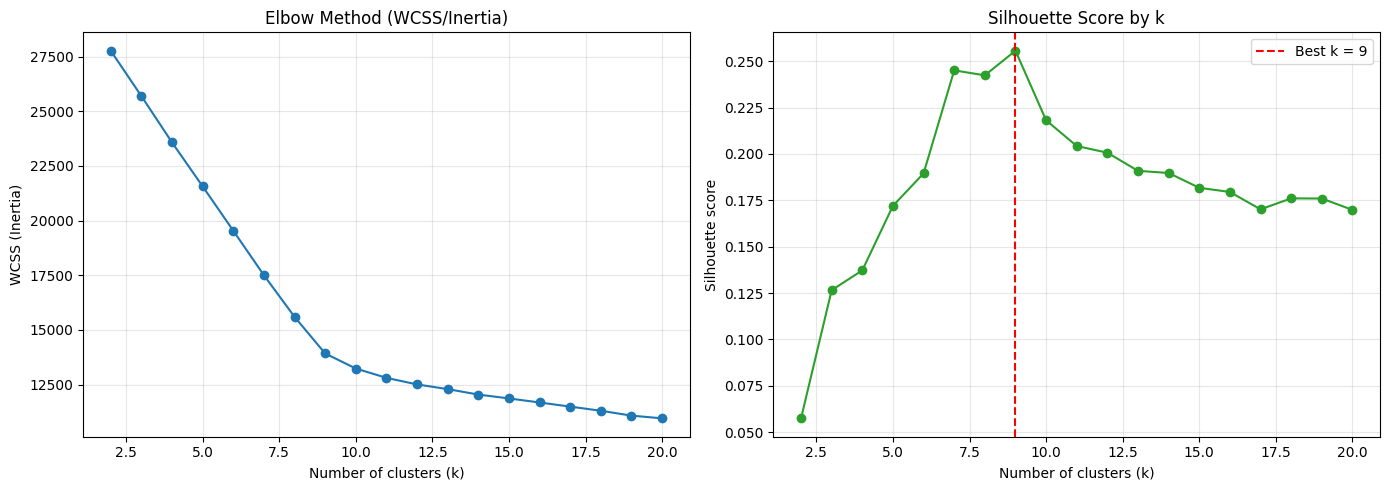

In [24]:
# KMeans model selection: elbow + silhouette, then visualize best k
from sklearn.decomposition import PCA

k_values = range(2, 21)  # expanded search range
wcss = []
silhouette_scores = []
models = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_scaled)
    models[k] = (km, labels)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, labels))

# Choose k with highest silhouette score
best_idx = int(np.argmax(silhouette_scores))
best_k = list(k_values)[best_idx]
km_best, y_best = models[best_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot (lower inertia is better)
axes[0].plot(list(k_values), wcss, marker='o')
axes[0].set_title('Elbow Method (WCSS/Inertia)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].grid(alpha=0.3)

# Silhouette plot (higher is better)
axes[1].plot(list(k_values), silhouette_scores, marker='o', color='tab:green')
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
print(f'Best k based on silhouette score: {best_k} (score={silhouette_scores[best_idx]:.3f})')





### Cluster Interpretation

Using both model-selection metrics, the best number of clusters is **k = 9**. The silhouette score reaches its maximum at k=9 (about 0.256), and the elbow curve starts to flatten around 9-10, indicating diminishing returns from adding more clusters.

In [25]:
# K-means cluster characteristics and effect of k
# Re-load original data for human-readable cluster profiling
raw = pd.read_csv('data/Customers.csv').copy()
raw['kmeans_cluster'] = y_best

numeric_cols = ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size']
available_numeric = [c for c in numeric_cols if c in raw.columns]

cluster_profile = raw.groupby('kmeans_cluster')[available_numeric].mean().round(2)
cluster_sizes = raw['kmeans_cluster'].value_counts().sort_index()

print('Cluster sizes (k-means):')
print(cluster_sizes)
print('\nCluster profile means:')
display(cluster_profile)

# Show how k changes segmentation quality/complexity
metrics_df = pd.DataFrame({
    'k': list(k_values),
    'inertia_wcss': wcss,
    'silhouette': silhouette_scores
})
print('\nTop 5 k values by silhouette score:')
display(metrics_df.sort_values('silhouette', ascending=False).head(5))

Cluster sizes (k-means):
kmeans_cluster
0     85
1    142
2    339
3    234
4    179
5    161
6    153
7    647
8     60
Name: count, dtype: int64

Cluster profile means:


,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
kmeans_cluster,,,,,
0,45.82,107994.21,48.72,4.31,3.73
1,47.75,110995.84,48.86,3.53,3.62
2,47.84,112574.04,50.52,4.00,3.91
3,51.16,110650.33,52.94,3.50,3.89
4,55.09,111161.24,48.97,3.96,3.58
5,46.62,111573.22,51.90,4.30,3.67
6,46.60,113770.13,49.90,4.25,3.97
7,49.20,109234.08,52.23,4.24,3.69
8,45.37,108758.62,46.38,6.13,4.05



Top 5 k values by silhouette score:


,k,inertia_wcss,silhouette
7,9,13925.156792,0.255643
5,7,17504.635494,0.245046
6,8,15601.479168,0.242375
8,10,13237.192771,0.218141
9,11,12809.640012,0.204272


### K-Means Interpretation

Customers are grouped into **9 segments** with different average age, income, spending score, work experience, and family size. The `cluster_profile` table summarizes what each cluster represents (for example, higher-income/high-spending groups versus lower-spending groups).

The choice of **k** changes both detail and quality: lower k merges distinct behaviors into broad groups, while higher k creates more granular segments. In this dataset, silhouette peaks at **k=9**, and after that the scores generally decline, suggesting over-segmentation beyond this point.

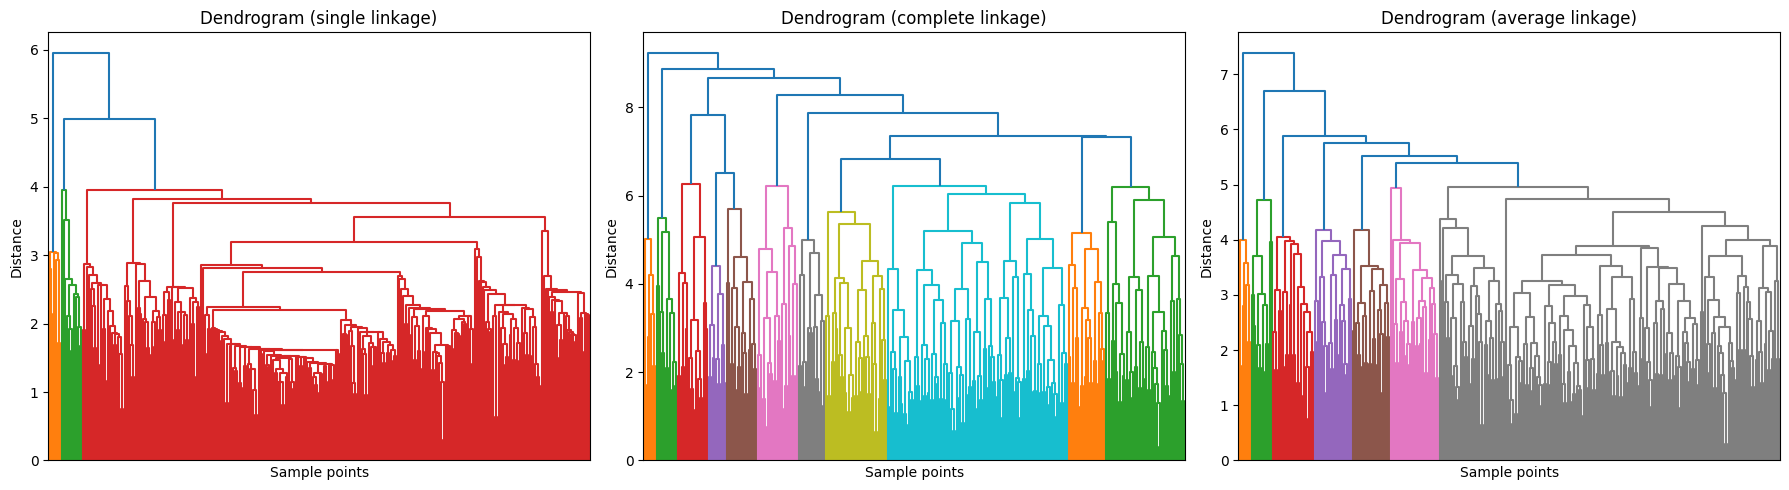

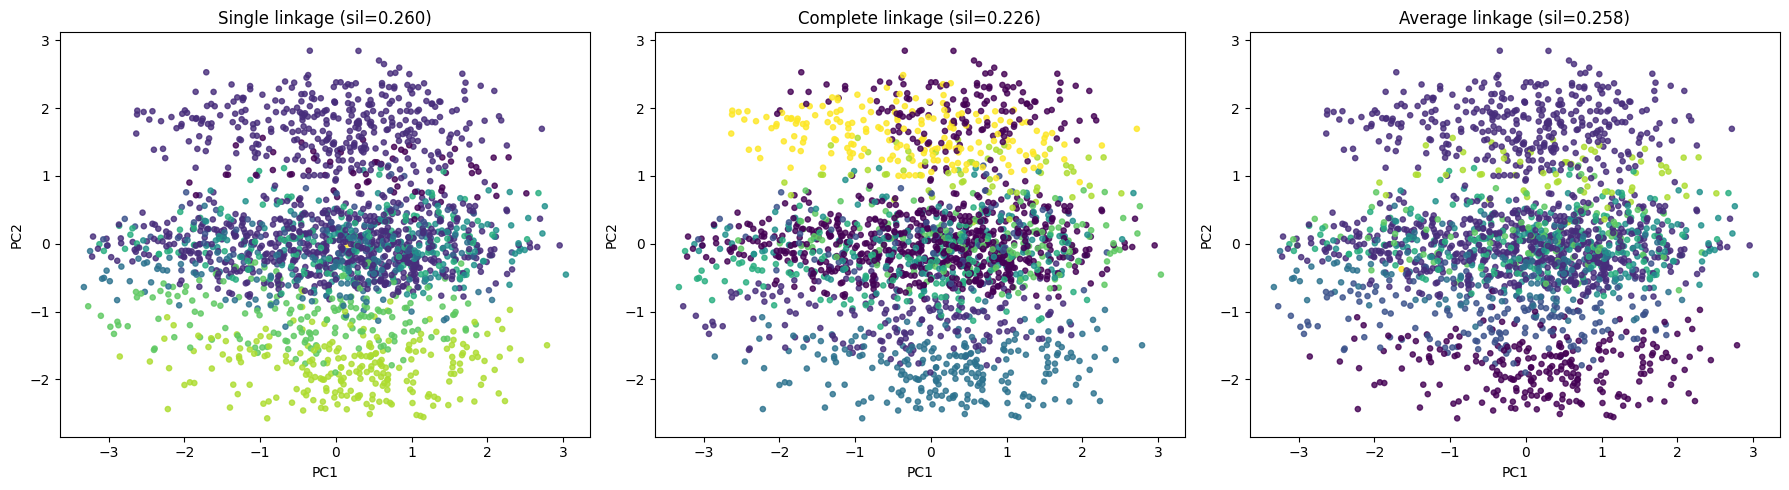

In [26]:
# Hierarchical clustering: single, complete, and average linkage
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['single', 'complete', 'average']

# Use a sample for readable dendrograms
np.random.seed(42)
sample_size = min(300, data_scaled.shape[0])
sample_idx = np.random.choice(data_scaled.shape[0], size=sample_size, replace=False)
X_sample = data_scaled[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_sample, method=method, metric='euclidean')
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=None)
    ax.set_title(f'Dendrogram ({method} linkage)')
    ax.set_xlabel('Sample points')
    ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# Compare cluster assignments in PCA space using same k as k-means
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    agg = AgglomerativeClustering(n_clusters=best_k, linkage=method)
    y_hier = agg.fit_predict(data_scaled)
    sil = silhouette_score(data_scaled, y_hier)

    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_hier, cmap='viridis', s=14, alpha=0.8)
    ax.set_title(f'{method.title()} linkage (sil={sil:.3f})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

### Hierarchical Clustering Interpretation

Agglomerative clustering builds groups bottom-up, and linkage controls how distances between clusters are measured:

- **Single linkage** tends to create chain-like clusters and is more sensitive to noise/outliers.
- **Complete linkage** tends to form compact, tighter clusters.
- **Average linkage** is usually a middle ground between single and complete.

Compared with k-means, hierarchical clustering does not require centroid updates and reveals merge structure through dendrograms. The dendrogram height indicates how dissimilar clusters are when merged, which helps identify natural cut points and compare whether customer segments are well separated or gradually connected.

Hierarchical clustering indicates moderate structure in the customer data. Single and average linkage produced better cohesion/separation than complete linkage (higher silhouette), but noticeable overlap in PCA space suggests segments are partially mixed rather than fully distinct.

# Part 3: Dimensionality Reduction Using PCA 

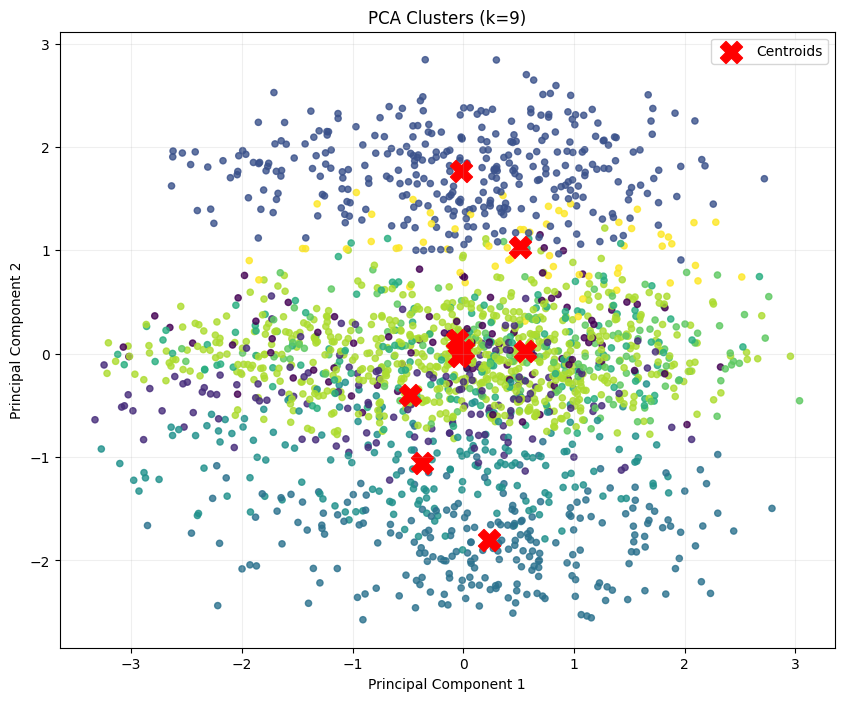

In [27]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(data_scaled)

# Project KMeans centroids into the same PCA space
centers_2d = pca.transform(km_best.cluster_centers_)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_best, cmap='viridis', s=20, alpha=0.8)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', s=250, marker='X', label='Centroids')
plt.title('PCA Clusters (k=9)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### PCA: Explained Variance and Component Interpretation

To evaluate dimensionality reduction, PCA is first applied across all components to measure explained variance. Then the first two principal components are visualized to show the dominant structure in the customer dataset.

Explained variance by principal component:


,PC,Explained Variance Ratio,Cumulative Variance
0,1,0.097710,0.097710
1,2,0.079632,0.177342
2,3,0.078006,0.255348
3,4,0.076186,0.331535
4,5,0.073189,0.404723
5,6,0.072483,0.477206
6,7,0.071913,0.549119
7,8,0.069893,0.619012
8,9,0.067317,0.686329
9,10,0.066265,0.752594


Variance captured by first two PCs: 0.177 (17.7%)


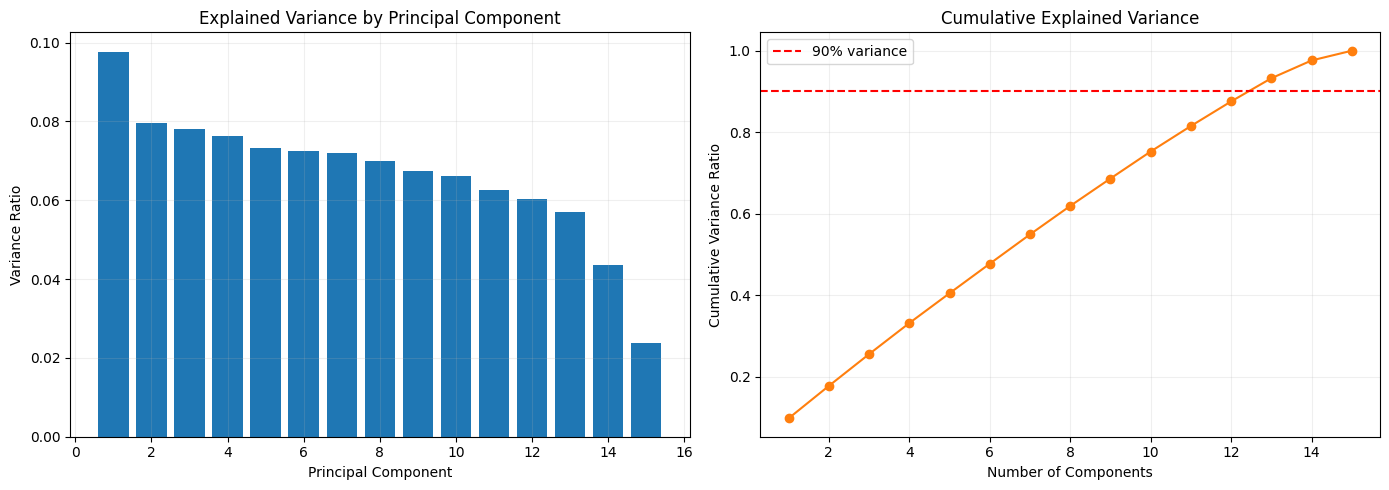

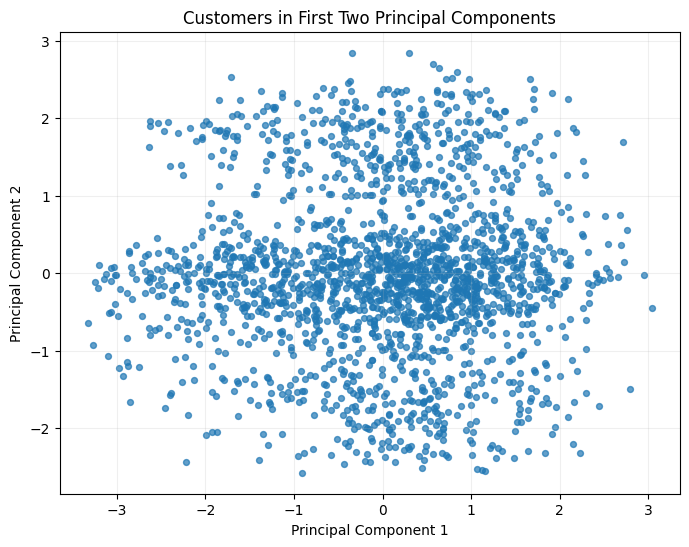

Top contributing features to PC1 and PC2 (by absolute loading):


,PC1 Loading,PC2 Loading
CustomerID,0.634707,-0.069854
Annual Income ($),0.582045,0.015525
Family Size,0.373016,0.026059
Work Experience,0.258309,0.231816
Age,0.129360,-0.277152
Profession_Executive,0.109080,0.005962
Profession_Lawyer,-0.090814,-0.092603
Profession_Engineer,-0.079853,-0.277231


,PC1 Loading,PC2 Loading
Profession_Healthcare,-0.006169,0.669038
Profession_Entertainment,0.058486,-0.550263
Profession_Engineer,-0.079853,-0.277231
Age,0.129360,-0.277152
Work Experience,0.258309,0.231816
Profession_Homemaker,0.061640,0.152355
Profession_Lawyer,-0.090814,-0.092603
CustomerID,0.634707,-0.069854


In [28]:
# Part 3.1-3.3: PCA variance analysis and visualization
from sklearn.decomposition import PCA

# Fit PCA using all features to inspect explained variance
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(data_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

variance_df = pd.DataFrame({
    'PC': np.arange(1, len(explained) + 1),
    'Explained Variance Ratio': explained,
    'Cumulative Variance': cumulative
})

print('Explained variance by principal component:')
display(variance_df.head(10))
print(f"Variance captured by first two PCs: {cumulative[1]:.3f} ({cumulative[1]*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(np.arange(1, len(explained) + 1), explained)
axes[0].set_title('Explained Variance by Principal Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].grid(alpha=0.2)

axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative, marker='o', color='tab:orange')
axes[1].axhline(0.90, linestyle='--', color='red', label='90% variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# First two principal components for visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(data_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], s=18, alpha=0.7)
plt.title('Customers in First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.2)
plt.show()

# Feature loadings to interpret what PCs represent
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=data.columns,
    columns=['PC1 Loading', 'PC2 Loading']
)
print('Top contributing features to PC1 and PC2 (by absolute loading):')
display(loadings.reindex(loadings['PC1 Loading'].abs().sort_values(ascending=False).index).head(8))
display(loadings.reindex(loadings['PC2 Loading'].abs().sort_values(ascending=False).index).head(8))

The first two principal components capture the largest share of variation in the dataset, but not all of it. This is why PCA is useful for visualization: it shows major structure while reducing dimensional complexity. The feature loadings indicate which original variables drive each component, helping interpret whether components reflect spending behavior, income level, age/life stage, or household/work characteristics.

Components kept for >=90% variance: 13
Original-space silhouette (k=9): 0.256
PCA-space silhouette (k=9): 0.246
Cluster agreement (Adjusted Rand Index): 1.000


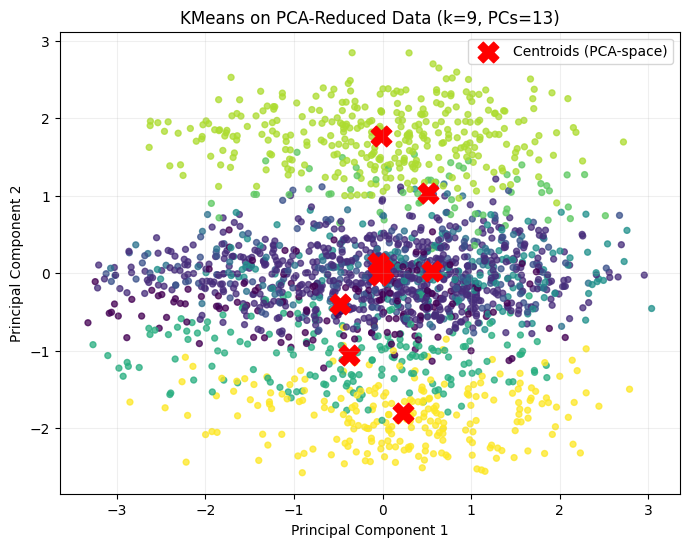

In [29]:
# Part 3.4-3.5: K-means on PCA-reduced data and comparison to original clustering
from sklearn.metrics import adjusted_rand_score

# Select number of PCs that preserve at least 90% variance
n_components_90 = int(np.argmax(cumulative >= 0.90) + 1)
pca_reduced = PCA(n_components=n_components_90, random_state=42)
X_reduced = pca_reduced.fit_transform(data_scaled)

# Run KMeans in reduced space using previously selected k
km_pca = KMeans(n_clusters=best_k, random_state=42, n_init=10)
y_pca = km_pca.fit_predict(X_reduced)

# Compare quality and agreement with original clusters
sil_orig = silhouette_score(data_scaled, y_best)
sil_pca = silhouette_score(X_reduced, y_pca)
ari = adjusted_rand_score(y_best, y_pca)

print(f'Components kept for >=90% variance: {n_components_90}')
print(f'Original-space silhouette (k={best_k}): {sil_orig:.3f}')
print(f'PCA-space silhouette (k={best_k}): {sil_pca:.3f}')
print(f'Cluster agreement (Adjusted Rand Index): {ari:.3f}')

# Visual comparison in 2D PCA view
centers_pca2 = km_pca.cluster_centers_[:, :2] if n_components_90 >= 2 else None

plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_pca, cmap='viridis', s=18, alpha=0.75)
if centers_pca2 is not None:
    plt.scatter(centers_pca2[:, 0], centers_pca2[:, 1], c='red', s=220, marker='X', label='Centroids (PCA-space)')
plt.title(f'KMeans on PCA-Reduced Data (k={best_k}, PCs={n_components_90})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Using PCA before clustering can reduce noise and redundancy, sometimes improving stability and interpretability. If PCA-space silhouette is similar to or higher than original-space silhouette, dimensionality reduction preserves useful structure while simplifying the model. The ARI value indicates how similar PCA-based clusters are to the original clusters (closer to 1 means stronger agreement).

# Part 4: Interpretation and Conclusion

### Cluster Interpretation and Business Implications

Across k-means and hierarchical clustering, the dataset shows multiple customer segments that differ in spending behavior, income, age, and household/work-related characteristics. These segments can support practical business actions:

- **Targeted marketing:** Promote premium products to higher-income/high-spending segments and value-focused campaigns to price-sensitive segments.
- **Retention strategies:** Identify lower-spending or less engaged segments and design loyalty incentives for them.
- **Personalization:** Tailor communication channels and offers based on segment behavior patterns.
- **Resource allocation:** Prioritize products and services for segments with stronger lifetime value potential.

### Real-World Application of Unsupervised Learning (Outside Customer Data)

A strong example is **healthcare patient stratification** using electronic health records (EHR) that contain lab values, vitals, demographics, medication history, and diagnosis patterns without predefined labels for risk subtypes.

- **Clustering** can identify patient subgroups with similar disease progression or treatment response profiles.
- **PCA** can reduce many correlated medical variables into fewer components for visualization and downstream modeling.

These techniques can help clinicians discover hidden patterns, design subgroup-specific interventions, and improve preventive care planning.